# Fabric Defect Detection and Localisation
CO 5420 — Project Pipeline using Classical Machine Learning

## 1. Setup & Data Loading

### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Extract Dataset

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/CO5420 Fabric.zip"
extract_path = "/content/CO5420 Fabric"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


### Import Core Libraries

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm

### Dataset Loader (Images and Masks)

In [4]:
def load_dataset(dataset_path):
    image_paths = []
    labels = []
    mask_paths = []

    # Collect ALL file paths in the dataset directory for debugging and robust matching
    all_files = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            all_files.append(os.path.join(root, file))

    # Print first 15 files found to let us inspect the structure in Colab
    print("--- Dataset Directory Diagnostics (First 15 files) ---")
    for f in all_files[:15]:
        print(f)
    print("---------------------------------------------------")

    # Classify files as masks if they contain 'mask' anywhere in their path
    mask_files = [f for f in all_files if "mask" in f.lower()]
    print(f"Found {len(mask_files)} files containing 'mask' in their path.\n")

    # Precompute a dictionary of mask stem names (without _mask, mask, extension, etc.) to full paths
    mask_map = {}
    for m_file in mask_files:
        m_name = os.path.splitext(os.path.basename(m_file))[0].lower()
        # Clean up common mask naming patterns to get the raw image base name
        # e.g., '0001_019_03_mask' -> '0001_019_03'
        clean_name = m_name.replace("_mask", "").replace("mask", "").strip("_")
        mask_map[clean_name] = m_file

    # Iterate and match
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(".png") and not "mask" in file.lower() and not "mask" in root.lower():
                path = os.path.join(root, file)
                base_name = os.path.splitext(file)[0].lower() # e.g. '0001_019_03'

                if "defect_free" in root.lower() or "normal" in root.lower() or "defectfree" in root.lower():
                    image_paths.append(path)
                    labels.append(0)
                    mask_paths.append(None)
                elif "defective" in root.lower() or "defect" in root.lower():
                    image_paths.append(path)
                    labels.append(1)

                    # Match mask based on clean exact name matching
                    matched_mask = mask_map.get(base_name, None)
                    mask_paths.append(matched_mask)

    df = pd.DataFrame({
        "image_path": image_paths,
        "mask_path": mask_paths,
        "label": labels
    })

    # Diagnostic check for unmatched defective images
    unmatched = df[(df.label == 1) & (df.mask_path.isna())]
    print(f"{len(unmatched)} defective images have no matched mask:")
    if len(unmatched) > 0:
        print(unmatched.image_path.tolist())
    return df

### Load and Inspect Dataset

In [5]:
DATASET_PATH = "/content/CO5420 Fabric"
df = load_dataset(DATASET_PATH)
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df["label"].value_counts())
matched_masks = df["mask_path"].notna().sum()
defective_count = (df["label"] == 1).sum()
print(f"\nSuccessfully matched {matched_masks} mask files out of {defective_count} defective images.")
df.head()

--- Dataset Directory Diagnostics (First 15 files) ---
/content/CO5420 Fabric/Test/test_0021.png
/content/CO5420 Fabric/Test/test_0028.png
/content/CO5420 Fabric/Test/test_0073.png
/content/CO5420 Fabric/Test/test_0017.png
/content/CO5420 Fabric/Test/test_0061.png
/content/CO5420 Fabric/Test/test_0012.png
/content/CO5420 Fabric/Test/test_0027.png
/content/CO5420 Fabric/Test/test_0039.png
/content/CO5420 Fabric/Test/test_0060.png
/content/CO5420 Fabric/Test/test_0044.png
/content/CO5420 Fabric/Test/test_0007.png
/content/CO5420 Fabric/Test/test_0041.png
/content/CO5420 Fabric/Test/test_0030.png
/content/CO5420 Fabric/Test/test_0071.png
/content/CO5420 Fabric/Test/test_0051.png
---------------------------------------------------
Found 0 files containing 'mask' in their path.

74 defective images have no matched mask:
['/content/CO5420 Fabric/Train/defective/defective_0041.png', '/content/CO5420 Fabric/Train/defective/defective_0026.png', '/content/CO5420 Fabric/Train/defective/defective_

,image_path,mask_path,label
0,/content/CO5420 Fabric/Train/defective/defecti...,None,1
1,/content/CO5420 Fabric/Train/defective/defecti...,None,1
2,/content/CO5420 Fabric/Train/defective/defecti...,None,1
3,/content/CO5420 Fabric/Train/defective/defecti...,None,1
4,/content/CO5420 Fabric/Train/defective/defecti...,None,1


## 2. Image Preprocessing & Contrast Enhancement

In [6]:
def preprocess_image(image_path, resize=(1024,64), blur=True):
    image = cv2.imread(image_path)
    if image is None: return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, resize)
    if blur:
        gray = cv2.GaussianBlur(gray, (3,3), 0)
    # Apply CLAHE to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    gray = gray.astype(np.float32)/255.0
    return gray

def preprocess_mask(mask_path, resize=(1024,64)):
    if mask_path is None or pd.isna(mask_path):
        return np.zeros((resize[1], resize[0]), dtype=np.uint8)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return np.zeros((resize[1], resize[0]), dtype=np.uint8)
    mask = cv2.resize(mask, resize)
    # Any value greater than 0 is a defect pixel (very robust against low intensities)
    _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)
    return mask

### Visualize Preprocessing Result

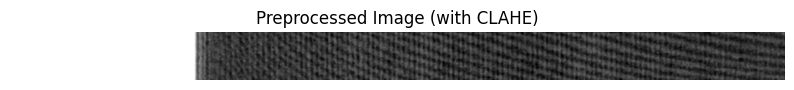

In [7]:
sample = df.iloc[0]
img = preprocess_image(sample.image_path)
plt.figure(figsize=(10,4))
plt.imshow(img, cmap="gray")
plt.title("Preprocessed Image (with CLAHE)")
plt.axis("off")
plt.show()

## 3. Exploratory Data Analysis (EDA)

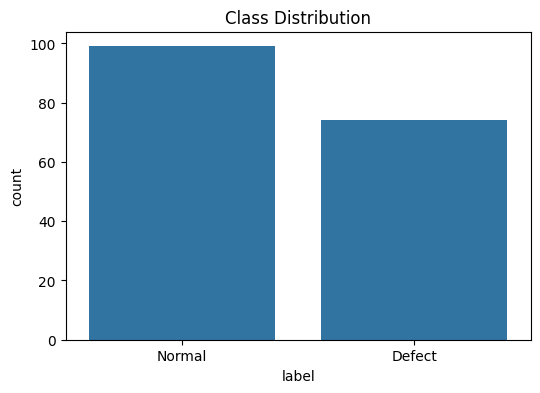

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.xticks([0,1], ["Normal","Defect"])
plt.title("Class Distribution")
plt.show()

### Sample Raw Images

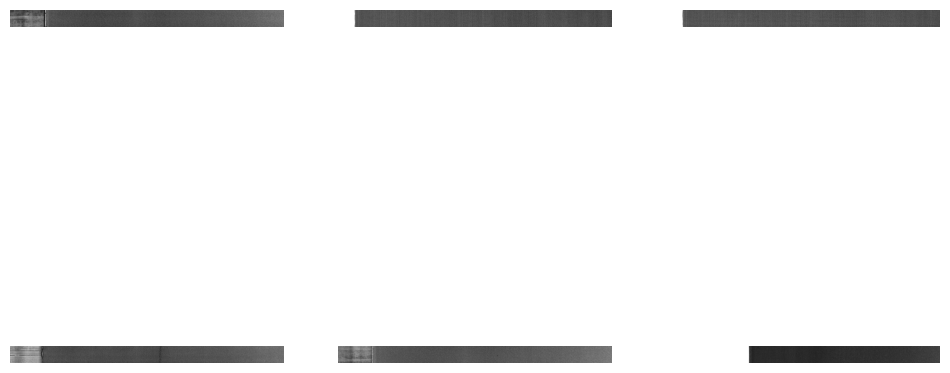

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))
normal = df[df.label==0].sample(3, random_state=42)
defect = df[df.label==1].sample(3, random_state=42)
samples = list(normal.image_path) + list(defect.image_path)

for ax, path in zip(axes.flatten(), samples):
    img = cv2.imread(path, 0)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.show()

## 4. Train-Validation-Test Split

In [10]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 121
Validation: 26
Testing: 26


### Save Split Metadata

In [11]:
OUTPUT_PATH = "/content/outputs"
os.makedirs(OUTPUT_PATH + "/processed_data", exist_ok=True)
train_df.to_csv(OUTPUT_PATH + "/processed_data/train.csv", index=False)
val_df.to_csv(OUTPUT_PATH + "/processed_data/val.csv", index=False)
test_df.to_csv(OUTPUT_PATH + "/processed_data/test.csv", index=False)
print("CSV splits saved.")

CSV splits saved.


## 5. Baseline Image Preprocessing & Feature Extraction

In [12]:
processed = []
labels = []
for index, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img = preprocess_image(row.image_path)
    if img is not None:
        processed.append(img)
        labels.append(row.label)
processed = np.array(processed)
labels = np.array(labels)
print("Processed Images Shape:", processed.shape)

100%|██████████| 121/121 [00:01<00:00, 69.66it/s]

Processed Images Shape: (121, 64, 1024)


In [13]:
np.save("/content/outputs/processed_data/images.npy", processed)
np.save("/content/outputs/processed_data/labels.npy", labels)
print("Saved training arrays.")

Saved training arrays.


In [14]:
!pip install scikit-image

### Feature Extractor Functions (LBP, GLCM, HOG)

In [15]:
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog

def extract_lbp(image):
    image = (image * 255).astype(np.uint8)
    radius = 3
    points = 8 * radius
    lbp = local_binary_pattern(image, points, radius, method="uniform")
    hist, bins = np.histogram(lbp.ravel(), bins=points+2, range=(0, points+2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)
    return hist

def extract_glcm(image):
    image = (image*255).astype(np.uint8)
    glcm = graycomatrix(image, distances=[1,3,5], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
    features = []
    properties = ["contrast", "correlation", "energy", "homogeneity"]
    for prop in properties:
        values = graycoprops(glcm, prop)
        features.extend(values.flatten())
    return np.array(features)

def extract_hog(image):
    image = (image*255).astype(np.uint8)
    features = hog(image, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), block_norm="L2-Hys")
    return features

def extract_all_features(image):
    return np.concatenate([
        extract_lbp(image),
        extract_glcm(image),
        extract_hog(image)
    ])

### Extract Baseline Features

In [16]:
X = []
y = []
for img, label in tqdm(zip(processed, labels), total=len(processed)):
    X.append(extract_all_features(img))
    y.append(label)
X = np.array(X)
y = np.array(y)
print("Feature Matrix shape:", X.shape)

100%|██████████| 121/121 [00:35<00:00,  3.36it/s]

Feature Matrix shape: (121, 6878)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
import joblib
joblib.dump(scaler, "/content/outputs/processed_data/scaler.pkl")
np.save("/content/outputs/processed_data/X_scaled.npy", X_scaled)
np.save("/content/outputs/processed_data/y_features.npy", y)
print("Scaler and normalized features saved.")

Scaler and normalized features saved.


## 6. Baseline Models (Image-Level Features)

In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluate_model(name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5

    print("="*50)
    print(name)
    print("="*50)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC": auc
    }

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42, stratify=y)

# SVM Baseline
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]
svm_results = evaluate_model("SVM Baseline", y_test, svm_pred, svm_prob)

# RF Baseline
rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_results = evaluate_model("Random Forest Baseline", y_test, rf_pred, rf_prob)

SVM Baseline
Accuracy: 0.5789
Precision: 0.5000
Recall: 0.3750
F1 Score: 0.4286
ROC-AUC: 0.8182

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.73      0.67        11
           1       0.50      0.38      0.43         8

    accuracy                           0.58        19
   macro avg       0.56      0.55      0.55        19
weighted avg       0.57      0.58      0.57        19

Random Forest Baseline
Accuracy: 0.6842
Precision: 0.7500
Recall: 0.3750
F1 Score: 0.5000
ROC-AUC: 0.8182

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.91      0.77        11
           1       0.75      0.38      0.50         8

    accuracy                           0.68        19
   macro avg       0.71      0.64      0.63        19
weighted avg       0.70      0.68      0.66        19



### Save and Visualize Baseline Results

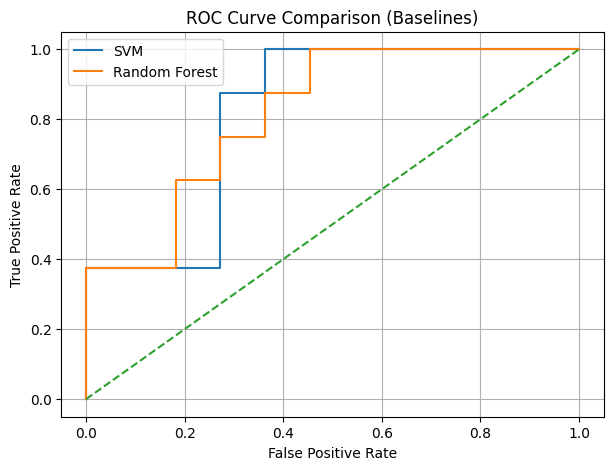

In [20]:
baseline_results = pd.DataFrame([svm_results, rf_results])
baseline_results.to_csv("/content/outputs/classical_results.csv", index=False)
joblib.dump(svm_model, "/content/outputs/svm_model.pkl")
joblib.dump(rf_model, "/content/outputs/random_forest_model.pkl")

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(svm_fpr, svm_tpr, label="SVM")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Baselines)")
plt.legend()
plt.grid()
plt.show()

## 7. Advanced Pipeline: Patches + Mask Labeling + Gabor Features

In [21]:
from skimage.filters import gabor

def create_patches(image, mask, patch_width=128, stride=64):
    img_patches = []
    mask_patches = []
    height, width = image.shape
    for start in range(0, width-patch_width+1, stride):
        img_patch = image[:, start:start+patch_width]
        mask_patch = mask[:, start:start+patch_width]
        img_patches.append(img_patch)
        mask_patches.append(mask_patch)
    return img_patches, mask_patches

def get_patch_label(mask_patch, threshold=0.02):
    # Calculate defect pixel fraction in the patch
    frac = mask_patch.sum() / 255.0 / mask_patch.size
    return int(frac > threshold)

def extract_gabor(image):
    features = []
    frequencies = [0.1, 0.3, 0.5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    for freq in frequencies:
        for theta in angles:
            real, imag = gabor(image, frequency=freq, theta=theta)
            features.append(real.mean())
            features.append(real.var())
    return np.array(features)

def extract_improved_features(image):
    return np.concatenate([
        extract_lbp(image),
        extract_glcm(image),
        extract_hog(image),
        extract_gabor(image)
    ])

### Build Patch Dataset from Splits

In [22]:
def process_df_to_images(df):
    images, masks, labels = [], [], []
    for index, row in df.iterrows():
        img = preprocess_image(row.image_path)
        mask = preprocess_mask(row.mask_path) if 'mask_path' in row else np.zeros(img.shape, dtype=np.uint8)
        if img is not None:
            images.append(img)
            masks.append(mask)
            labels.append(row.label)
    return images, masks, labels

print("Processing datasets to full images...")
train_imgs, train_masks, train_img_labels = process_df_to_images(train_df)
val_imgs, val_masks, val_img_labels = process_df_to_images(val_df)
test_imgs, test_masks, test_img_labels = process_df_to_images(test_df)

def build_patch_dataset(images, masks, img_labels):
    X, y, groups = [], [], []
    for img_idx, (img, mask, img_lbl) in enumerate(zip(images, masks, img_labels)):
        img_patches, mask_patches = create_patches(img, mask)
        for i_patch, m_patch in zip(img_patches, mask_patches):
            X.append(extract_improved_features(i_patch))
            # Use image-level label as fallback when masks are empty/not loaded
            if mask is not None and mask.sum() > 0:
                y.append(get_patch_label(m_patch))
            else:
                y.append(img_lbl)
            groups.append(img_idx)
    return np.array(X), np.array(y), np.array(groups)

print("Extracting patches and building datasets...")
X_train_raw, y_train, train_groups = build_patch_dataset(train_imgs, train_masks, train_img_labels)
X_val_raw, y_val, val_groups = build_patch_dataset(val_imgs, val_masks, val_img_labels)
X_test_raw, y_test, test_groups = build_patch_dataset(test_imgs, test_masks, test_img_labels)

print("Train patches shape:", X_train_raw.shape)
print("Val patches shape:", X_val_raw.shape)
print("Test patches shape:", X_test_raw.shape)


Processing datasets to full images...
Extracting patches and building datasets...
Train patches shape: (1815, 854)
Val patches shape: (390, 854)
Test patches shape: (390, 854)


### Scaling and Supervised Feature Selection (SelectKBest)

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

scaler = StandardScaler().fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

selector = SelectKBest(f_classif, k=150).fit(X_train_scaled, y_train)
X_train_pca = selector.transform(X_train_scaled)
X_val_pca = selector.transform(X_val_scaled)
X_test_pca = selector.transform(X_test_scaled)

print("Selected Features Shape:", X_train_pca.shape)

Selected Features Shape: (1815, 150)


### Apply SMOTE (Training set only)

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import NearestNeighbors

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

# Align group IDs for CV
nn = NearestNeighbors(n_neighbors=1).fit(X_train_pca)
_, indices = nn.kneighbors(X_train_resampled)
train_groups_resampled = train_groups[indices.flatten()]

print("Training size after SMOTE:", X_train_resampled.shape)
print("Class distribution:", np.bincount(y_train_resampled))


Training size after SMOTE: (2070, 150)
Class distribution: [1035 1035]


## 8. Improved Model Training & Double Threshold Optimization

In [25]:
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

def aggregate_to_image_level(patch_probs, groups, img_labels, method="mean", k=2):
    df = pd.DataFrame({"prob": patch_probs, "group": groups})
    if method == "max":
        image_probs = df.groupby("group")["prob"].max().values
    elif method == "topk":
        image_probs = df.groupby("group")["prob"].apply(lambda x: x.nlargest(min(k, len(x))).mean()).values
    else:
        image_probs = df.groupby("group")["prob"].mean().values
    image_true = [img_labels[g] for g in sorted(set(groups))]
    return image_probs, image_true

### A. Improved SVM

In [27]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

svm = SVC(probability=True, class_weight="balanced")
svm_params = {
    "C": [0.05, 0.1, 1, 5, 10],
    "gamma": ["scale", "auto", 0.01, 0.001],
    "kernel": ["rbf"]
}
svm_grid = GridSearchCV(svm, svm_params, cv=sgkf, scoring="f1", n_jobs=-1)
svm_grid.fit(X_train_resampled, y_train_resampled, groups=train_groups_resampled)
best_svm = svm_grid.best_estimator_
print("Best SVM Params:", svm_grid.best_params_)

from sklearn.metrics import precision_recall_curve

# 1. Patch-level threshold
val_prob_svm_patch = best_svm.predict_proba(X_val_pca)[:, 1]
precisions_patch, recalls_patch, thresholds_patch = precision_recall_curve(y_val, val_prob_svm_patch)
f1_patch = (2 * precisions_patch[:-1] * recalls_patch[:-1]) / (precisions_patch[:-1] + recalls_patch[:-1] + 1e-8)
best_threshold_svm = thresholds_patch[np.argmax(f1_patch)] if len(thresholds_patch)>0 else 0.5
print(f"Best SVM Patch Threshold: {best_threshold_svm:.4f}")

# 2. Image-level threshold & aggregation selection
best_method_svm, best_f1_svm, best_threshold_img_svm = None, -1, 0.5
for method in ["mean", "max", "topk"]:
    val_img_probs, val_img_true = aggregate_to_image_level(val_prob_svm_patch, val_groups, val_img_labels, method=method)
    precisions_img, recalls_img, thresholds_img = precision_recall_curve(val_img_true, val_img_probs)
    f1_img = (2 * precisions_img[:-1] * recalls_img[:-1]) / (precisions_img[:-1] + recalls_img[:-1] + 1e-8)
    if len(f1_img) > 0 and np.max(f1_img) > best_f1_svm:
        best_f1_svm = np.max(f1_img)
        best_method_svm = method
        best_threshold_img_svm = thresholds_img[np.argmax(f1_img)]

print(f"SVM: chose {best_method_svm} aggregation, threshold {best_threshold_img_svm:.4f}, val F1 {best_f1_svm:.4f}")

# Test evaluation
svm_prob = best_svm.predict_proba(X_test_pca)[:, 1]
svm_pred = (svm_prob >= best_threshold_svm).astype(int)
print("\n--- PATCH LEVEL EVALUATION ---")
svm_results = evaluate_model("Improved SVM (Patch)", y_test, svm_pred, svm_prob)

img_probs_svm, img_true = aggregate_to_image_level(svm_prob, test_groups, test_img_labels, method=best_method_svm)
img_pred_svm = (img_probs_svm >= best_threshold_img_svm).astype(int)
print(f"\n--- IMAGE LEVEL EVALUATION ({best_method_svm.upper()} AGGREGATION) ---")
svm_img_results = evaluate_model("Improved SVM (Image)", img_true, img_pred_svm, img_probs_svm)

Best SVM Params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM Patch Threshold: 0.0725
SVM: chose mean aggregation, threshold 0.2607, val F1 0.6667

--- PATCH LEVEL EVALUATION ---
Improved SVM (Patch)
Accuracy: 0.4615
Precision: 0.4390
Recall: 0.9818
F1 Score: 0.6067
ROC-AUC: 0.7894

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.08      0.15       225
           1       0.44      0.98      0.61       165

    accuracy                           0.46       390
   macro avg       0.65      0.53      0.38       390
weighted avg       0.68      0.46      0.34       390


--- IMAGE LEVEL EVALUATION (MEAN AGGREGATION) ---
Improved SVM (Image)
Accuracy: 0.5385
Precision: 0.4783
Recall: 1.0000
F1 Score: 0.6471
ROC-AUC: 0.8848

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.20      0.33        15
           1       0.48      1.00      0.65        11

    accuracy   

### B. Improved Random Forest

In [28]:
rf = RandomForestClassifier(class_weight="balanced", random_state=42, bootstrap=True)
rf_params = {
    "n_estimators": [200, 300],
    "max_depth": [5, 8, 12, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"]
}
rf_grid = GridSearchCV(rf, rf_params, cv=sgkf, scoring="f1", n_jobs=-1)
rf_grid.fit(X_train_resampled, y_train_resampled, groups=train_groups_resampled)
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)

# Print top 15 features to check descriptive importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\n--- RANDOM FOREST TOP 15 FEATURE IMPORTANCES ---")
for rank in range(15):
    print(f"Rank {rank+1}: Feature {indices[rank]} (Importance: {importances[indices[rank]]:.4f})")

# 1. Patch-level threshold
val_prob_rf_patch = best_rf.predict_proba(X_val_pca)[:, 1]
precisions_patch, recalls_patch, thresholds_patch = precision_recall_curve(y_val, val_prob_rf_patch)
f1_patch = (2 * precisions_patch[:-1] * recalls_patch[:-1]) / (precisions_patch[:-1] + recalls_patch[:-1] + 1e-8)
best_threshold_rf = thresholds_patch[np.argmax(f1_patch)] if len(thresholds_patch)>0 else 0.5
print(f"Best RF Patch Threshold: {best_threshold_rf:.4f}")

# 2. Image-level threshold & aggregation selection
best_method_rf, best_f1_rf, best_threshold_img_rf = None, -1, 0.5
for method in ["mean", "max", "topk"]:
    val_img_probs, val_img_true = aggregate_to_image_level(val_prob_rf_patch, val_groups, val_img_labels, method=method)
    precisions_img, recalls_img, thresholds_img = precision_recall_curve(val_img_true, val_img_probs)
    f1_img = (2 * precisions_img[:-1] * recalls_img[:-1]) / (precisions_img[:-1] + recalls_img[:-1] + 1e-8)
    if len(f1_img) > 0 and np.max(f1_img) > best_f1_rf:
        best_f1_rf = np.max(f1_img)
        best_method_rf = method
        best_threshold_img_rf = thresholds_img[np.argmax(f1_img)]

print(f"RF: chose {best_method_rf} aggregation, threshold {best_threshold_img_rf:.4f}, val F1 {best_f1_rf:.4f}")

# Test evaluation
rf_prob = best_rf.predict_proba(X_test_pca)[:, 1]
rf_pred = (rf_prob >= best_threshold_rf).astype(int)
print("\n--- PATCH LEVEL EVALUATION ---")
rf_results = evaluate_model("Improved RF (Patch)", y_test, rf_pred, rf_prob)

img_probs_rf, img_true = aggregate_to_image_level(rf_prob, test_groups, test_img_labels, method=best_method_rf)
img_pred_rf = (img_probs_rf >= best_threshold_img_rf).astype(int)
print(f"\n--- IMAGE LEVEL EVALUATION ({best_method_rf.upper()} AGGREGATION) ---")
rf_img_results = evaluate_model("Improved RF (Image)", img_true, img_pred_rf, img_probs_rf)

Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

--- RANDOM FOREST TOP 15 FEATURE IMPORTANCES ---
Rank 1: Feature 1 (Importance: 0.0245)
Rank 2: Feature 2 (Importance: 0.0235)
Rank 3: Feature 146 (Importance: 0.0228)
Rank 4: Feature 148 (Importance: 0.0226)
Rank 5: Feature 145 (Importance: 0.0214)
Rank 6: Feature 149 (Importance: 0.0203)
Rank 7: Feature 3 (Importance: 0.0192)
Rank 8: Feature 0 (Importance: 0.0190)
Rank 9: Feature 7 (Importance: 0.0182)
Rank 10: Feature 144 (Importance: 0.0165)
Rank 11: Feature 143 (Importance: 0.0148)
Rank 12: Feature 9 (Importance: 0.0148)
Rank 13: Feature 10 (Importance: 0.0139)
Rank 14: Feature 32 (Importance: 0.0123)
Rank 15: Feature 8 (Importance: 0.0119)
Best RF Patch Threshold: 0.2994
RF: chose max aggregation, threshold 0.4708, val F1 0.7097

--- PATCH LEVEL EVALUATION ---
Improved RF (Patch)
Accuracy: 0.6154
Precision: 0.5243
Recall: 0.9818
F1 Score: 0.6835
ROC-AUC

### C. XGBoost Classifier

In [29]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
xgb.fit(X_train_resampled, y_train_resampled)

# 1. Patch-level threshold
val_prob_xgb_patch = xgb.predict_proba(X_val_pca)[:, 1]
precisions_patch, recalls_patch, thresholds_patch = precision_recall_curve(y_val, val_prob_xgb_patch)
f1_patch = (2 * precisions_patch[:-1] * recalls_patch[:-1]) / (precisions_patch[:-1] + recalls_patch[:-1] + 1e-8)
best_threshold_xgb = thresholds_patch[np.argmax(f1_patch)] if len(thresholds_patch)>0 else 0.5
print(f"Best XGB Patch Threshold: {best_threshold_xgb:.4f}")

# 2. Image-level threshold & aggregation selection
best_method_xgb, best_f1_xgb, best_threshold_img_xgb = None, -1, 0.5
for method in ["mean", "max", "topk"]:
    val_img_probs, val_img_true = aggregate_to_image_level(val_prob_xgb_patch, val_groups, val_img_labels, method=method)
    precisions_img, recalls_img, thresholds_img = precision_recall_curve(val_img_true, val_img_probs)
    f1_img = (2 * precisions_img[:-1] * recalls_img[:-1]) / (precisions_img[:-1] + recalls_img[:-1] + 1e-8)
    if len(f1_img) > 0 and np.max(f1_img) > best_f1_xgb:
        best_f1_xgb = np.max(f1_img)
        best_method_xgb = method
        best_threshold_img_xgb = thresholds_img[np.argmax(f1_img)]

print(f"XGB: chose {best_method_xgb} aggregation, threshold {best_threshold_img_xgb:.4f}, val F1 {best_f1_xgb:.4f}")

# Test evaluation
xgb_prob = xgb.predict_proba(X_test_pca)[:, 1]
xgb_pred = (xgb_prob >= best_threshold_xgb).astype(int)
print("\n--- PATCH LEVEL EVALUATION ---")
xgb_results = evaluate_model("XGBoost (Patch)", y_test, xgb_pred, xgb_prob)

img_probs_xgb, img_true = aggregate_to_image_level(xgb_prob, test_groups, test_img_labels, method=best_method_xgb)
img_pred_xgb = (img_probs_xgb >= best_threshold_img_xgb).astype(int)
print(f"\n--- IMAGE LEVEL EVALUATION ({best_method_xgb.upper()} AGGREGATION) ---")
xgb_img_results = evaluate_model("XGBoost (Image)", img_true, img_pred_xgb, img_probs_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:11:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Patch Threshold: 0.0234
XGB: chose mean aggregation, threshold 0.1493, val F1 0.7097

--- PATCH LEVEL EVALUATION ---
XGBoost (Patch)
Accuracy: 0.6128
Precision: 0.5226
Recall: 0.9818
F1 Score: 0.6821
ROC-AUC: 0.8598

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.34      0.50       225
           1       0.52      0.98      0.68       165

    accuracy                           0.61       390
   macro avg       0.74      0.66      0.59       390
weighted avg       0.78      0.61      0.58       390


--- IMAGE LEVEL EVALUATION (MEAN AGGREGATION) ---
XGBoost (Image)
Accuracy: 0.6154
Precision: 0.5238
Recall: 1.0000
F1 Score: 0.6875
ROC-AUC: 0.9152

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50        15
           1       0.52      1.00      0.69        11

    accuracy                           0.62        26
   macro avg       0.76      0

### D. Voting Ensemble Classifier

In [30]:
from sklearn.ensemble import VotingClassifier
estimators = [
    ('svm', best_svm),
    ('rf', best_rf),
    ('xgb', xgb)
]
ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
ensemble.fit(X_train_resampled, y_train_resampled)

# 1. Patch-level threshold
val_prob_ens_patch = ensemble.predict_proba(X_val_pca)[:, 1]
precisions_patch, recalls_patch, thresholds_patch = precision_recall_curve(y_val, val_prob_ens_patch)
f1_patch = (2 * precisions_patch[:-1] * recalls_patch[:-1]) / (precisions_patch[:-1] + recalls_patch[:-1] + 1e-8)
best_threshold_ens = thresholds_patch[np.argmax(f1_patch)] if len(thresholds_patch)>0 else 0.5
print(f"Best Ensemble Patch Threshold: {best_threshold_ens:.4f}")

# 2. Image-level threshold & aggregation selection
best_method_ens, best_f1_ens, best_threshold_img_ens = None, -1, 0.5
for method in ["mean", "max", "topk"]:
    val_img_probs, val_img_true = aggregate_to_image_level(val_prob_ens_patch, val_groups, val_img_labels, method=method)
    precisions_img, recalls_img, thresholds_img = precision_recall_curve(val_img_true, val_img_probs)
    f1_img = (2 * precisions_img[:-1] * recalls_img[:-1]) / (precisions_img[:-1] + recalls_img[:-1] + 1e-8)
    if len(f1_img) > 0 and np.max(f1_img) > best_f1_ens:
        best_f1_ens = np.max(f1_img)
        best_method_ens = method
        best_threshold_img_ens = thresholds_img[np.argmax(f1_img)]

print(f"Ensemble: chose {best_method_ens} aggregation, threshold {best_threshold_img_ens:.4f}, val F1 {best_f1_ens:.4f}")

# Test evaluation
ensemble_prob = ensemble.predict_proba(X_test_pca)[:, 1]
ensemble_pred = (ensemble_prob >= best_threshold_ens).astype(int)
print("\n--- PATCH LEVEL EVALUATION ---")
ensemble_results = evaluate_model("Ensemble (Patch)", y_test, ensemble_pred, ensemble_prob)

img_probs_ens, img_true = aggregate_to_image_level(ensemble_prob, test_groups, test_img_labels, method=best_method_ens)
img_pred_ens = (img_probs_ens >= best_threshold_img_ens).astype(int)
print(f"\n--- IMAGE LEVEL EVALUATION ({best_method_ens.upper()} AGGREGATION) ---")
ensemble_img_results = evaluate_model("Ensemble (Image)", img_true, img_pred_ens, img_probs_ens)

# Bootstrapping the F1-score to calculate 95% Confidence Interval for Ensemble (Image)
from sklearn.utils import resample
f1_boot = []
for _ in range(1000):
    idx = resample(range(len(img_true)))
    f1_boot.append(f1_score(np.array(img_true)[idx], np.array(img_pred_ens)[idx], zero_division=0))
print("\n--- ENSEMBLE (IMAGE) F1-SCORE BOOTSTRAPPING ---")
print(f"Mean F1: {np.mean(f1_boot):.3f} (95% CI: {np.percentile(f1_boot, 2.5):.3f} - {np.percentile(f1_boot, 97.5):.3f})")

Best Ensemble Patch Threshold: 0.1542
Ensemble: chose mean aggregation, threshold 0.2480, val F1 0.6667

--- PATCH LEVEL EVALUATION ---
Ensemble (Patch)
Accuracy: 0.5487
Precision: 0.4838
Recall: 0.9939
F1 Score: 0.6508
ROC-AUC: 0.8538

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.22      0.36       225
           1       0.48      0.99      0.65       165

    accuracy                           0.55       390
   macro avg       0.73      0.61      0.51       390
weighted avg       0.77      0.55      0.48       390


--- IMAGE LEVEL EVALUATION (MEAN AGGREGATION) ---
Ensemble (Image)
Accuracy: 0.6154
Precision: 0.5238
Recall: 1.0000
F1 Score: 0.6875
ROC-AUC: 0.9091

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50        15
           1       0.52      1.00      0.69        11

    accuracy                           0.62        26
   macro avg      

## 9. Final Model Comparison

In [31]:
comparison = pd.DataFrame([
    svm_results,
    rf_results,
    xgb_results,
    ensemble_results,
    svm_img_results,
    rf_img_results,
    xgb_img_results,
    ensemble_img_results
])
comparison.to_csv("/content/outputs/improved_classical_results.csv", index=False)
comparison

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Improved SVM (Patch),0.461538,0.439024,0.981818,0.606742,0.789387
1,Improved RF (Patch),0.615385,0.524272,0.981818,0.683544,0.831515
2,XGBoost (Patch),0.612821,0.522581,0.981818,0.682105,0.859758
3,Ensemble (Patch),0.548718,0.483776,0.993939,0.650794,0.853845
4,Improved SVM (Image),0.538462,0.478261,1.000000,0.647059,0.884848
5,Improved RF (Image),0.538462,0.478261,1.000000,0.647059,0.830303
6,XGBoost (Image),0.615385,0.523810,1.000000,0.687500,0.915152
7,Ensemble (Image),0.615385,0.523810,1.000000,0.687500,0.909091


### Save final models and selectors

In [32]:
joblib.dump(best_svm, "/content/outputs/improved_svm.pkl")
joblib.dump(best_rf, "/content/outputs/improved_random_forest.pkl")
joblib.dump(xgb, "/content/outputs/xgb_model.pkl")
joblib.dump(ensemble, "/content/outputs/ensemble_model.pkl")
joblib.dump(selector, "/content/outputs/selector.pkl")
joblib.dump(scaler, "/content/outputs/scaler.pkl")
print("All improved models and prep pipelines saved successfully.")

All improved models and prep pipelines saved successfully.
